In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import os
from typing import Dict
import pickle
from scipy.stats import linregress

def make_path_exist(filepath):
    os.makedirs(os.path.dirname(filepath), exist_ok=True)

def set_default_plot_style():
    plt.style.use("default")  # start clean

    plt.rcParams["axes.grid"] = True
    plt.rcParams["grid.alpha"] = 0.2
    plt.rcParams["grid.linestyle"] = "-"
    plt.rcParams["grid.color"] = "gray"

    plt.rcParams["axes.spines.top"] = False
    plt.rcParams["axes.spines.right"] = False

    plt.rcParams["axes.linewidth"] = 1.2

    plt.rcParams["legend.frameon"] = False

    plt.rcParams["font.size"] = 23
    plt.rcParams["axes.labelsize"] = 30
    plt.rcParams["legend.fontsize"] = 21

    # plt.rcParams["font.size"] = 18
    # plt.rcParams["axes.labelsize"] = 24
    # plt.rcParams["legend.fontsize"] = 12

    mpl.rcParams['text.usetex'] = True
    mpl.rcParams['font.family'] = 'serif'
    mpl.rcParams['font.serif'] = ['Computer Modern Roman']

# Call once at the top of your script
set_default_plot_style()


In [3]:
# Helpful funcs
def log_b(x, b):
    return np.log(x) / np.log(b)


In [4]:
L_vals = [2000]
a_c = 0.75
a_vals = sorted(list(set([0.7535, 0.7555, 0.7575, 0.7595, 0.7615] + [0.757, 0.7572, 0.7574, 0.7576, 0.7578, 0.7579] + [0.75425, 0.75625, 0.758, 0.7581, 0.7582,  0.75825, 0.7583,  0.76025, 0.76225])))
a_vals = [0.7535, 0.7555, 0.757, 0.7572, 0.7574, 0.7575, 0.7576, 0.7578, 0.7579, 0.758, 0.7582, 0.7595, 0.7615]


N_val = 4

time_prefact = 5

num_initial_conds = 1700
num_init_conds_offset = 0

time_step = 1

cmaps = {2000: plt.colormaps.get_cmap("Oranges").resampled(len(a_vals) + 5), 512: plt.colormaps.get_cmap("Oranges").resampled(len(a_vals) + 5), 1024: plt.colormaps.get_cmap("Reds").resampled(len(a_vals) + 5)}

read_external_drive = True
write_external_drive = read_external_drive and True
local_data_parent_folder = "../data"
second_data_parent_folder = "/Volumes/ExternalData/s_diff_per_time/"
if read_external_drive:
    data_parent_folder = "/Volumes/ExternalData/s_diff_per_time/"
    if write_external_drive:
        local_data_parent_folder = "/Volumes/ExternalData/s_diff_per_time/"      
        second_data_parent_folder = "../data/s_diff_per_time/"
else:
    data_parent_folder = local_data_parent_folder

# If first time

In [27]:


collected_sdiffs = {}
collected_sdiff_stds = {}

counts = []
for L_val in L_vals:
    print(f"L_val: {L_val}")

    T_f = L_val*time_prefact
    collected_sdiffs[L_val] = {}
    collected_sdiff_stds[L_val] = {}

    collected_sdiffs[L_val] = {}
    collected_sdiff_stds[L_val] = {}

    for a_val in a_vals:
        print(f"L_val: {L_val} | a: {a_val}")
        a_val_name = f"{a_val}".replace(".", "p")

        current_sdiff = []
        c = 0
        for init_cond in range(1, num_initial_conds+1):
            sample_filepath_name = os.path.join(data_parent_folder, f"N{N_val}/a{a_val_name}/IC1/L{L_val}/N{N_val}_a{a_val_name}_IC1_L{L_val}_timepref{time_prefact}_timestep{time_step}_sample{init_cond}.csv")
                
            try:
                df = pd.read_csv(sample_filepath_name)

                current_sdiff.append(df.s_diff)
                c +=1
            except Exception as e:
                print(e)
                print(sample_filepath_name)
        counts.append(c)
        current_sdiff = np.array(current_sdiff)
        collected_sdiffs[L_val][a_val] = np.mean(current_sdiff.T, axis=1)
        collected_sdiff_stds[L_val][a_val] = np.std(current_sdiff.T, axis=1)

        pickle_path = os.path.join(local_data_parent_folder, f"N{N_val}/a{a_val_name}/IC{num_initial_conds}/L{L_val}/N{N_val}_IC{num_initial_conds}_L{L_val}_a{a_val_name}_timepref{time_prefact}_timestep{time_step}")
        second_pickle_path = os.path.join(second_data_parent_folder, f"N{N_val}/a{a_val_name}/IC{num_initial_conds}/L{L_val}/N{N_val}_IC{num_initial_conds}_L{L_val}_a{a_val_name}_timepref{time_prefact}_timestep{time_step}")
                                                                
        dir_path = os.path.dirname(pickle_path)
        os.makedirs(dir_path, exist_ok=True)
        
        with open(pickle_path + "mean.pickle", "wb") as f:
            pickle.dump(collected_sdiffs[L_val][a_val], f)
        with open(pickle_path + "stds.pickle", "wb") as f:
            pickle.dump(collected_sdiff_stds[L_val][a_val], f)

        try:
            dir_path = os.path.dirname(second_pickle_path)
            os.makedirs(dir_path, exist_ok=True)
            with open(second_pickle_path + "mean.pickle", "wb") as f:
                pickle.dump(collected_sdiffs[L_val][a_val], f)
            with open(second_pickle_path + "stds.pickle", "wb") as f:
                pickle.dump(collected_sdiff_stds[L_val][a_val], f)
        except Exception as E:
            print(E)
print(min(counts))

L_val: 2000
L_val: 2000 | a: 0.7535
L_val: 2000 | a: 0.7555
L_val: 2000 | a: 0.757
L_val: 2000 | a: 0.7572
L_val: 2000 | a: 0.7574
L_val: 2000 | a: 0.7575
L_val: 2000 | a: 0.7576
L_val: 2000 | a: 0.7578
L_val: 2000 | a: 0.7579
L_val: 2000 | a: 0.758
L_val: 2000 | a: 0.7582
L_val: 2000 | a: 0.7595
L_val: 2000 | a: 0.7615
1700


## If you have already processed and saved the data as pickled

In [5]:

collected_sdiffs = {}
collected_sdiff_stds = {}

for L_val in L_vals:
    print(f"L_val: {L_val}")

    T_f = L_val*time_prefact
    collected_sdiffs[L_val] = {}
    collected_sdiff_stds[L_val] = {}

    collected_sdiffs[L_val] = {}
    collected_sdiff_stds[L_val] = {}
    for a_val in a_vals:
        a_val_name = f"{a_val}".replace(".", "p")
        try:
            pickle_path = os.path.join(local_data_parent_folder, f"N{N_val}/a{a_val_name}/IC{num_initial_conds}/L{L_val}/N{N_val}_IC{num_initial_conds}_L{L_val}_a{a_val_name}_timepref{time_prefact}_timestep{time_step}")

            with open(pickle_path + "mean.pickle", "rb") as f:
                collected_sdiffs[L_val][a_val] = pickle.load(f)
            with open(pickle_path + "stds.pickle", "rb") as f:
                collected_sdiff_stds[L_val][a_val] = pickle.load(f)

        except:
            pickle_path = os.path.join(second_data_parent_folder, f"N{N_val}/a{a_val_name}/IC{num_initial_conds}/L{L_val}/N{N_val}_IC{num_initial_conds}_L{L_val}_a{a_val_name}_timepref{time_prefact}_timestep{time_step}")

            with open(pickle_path + "mean.pickle", "rb") as f:
                collected_sdiffs[L_val][a_val] = pickle.load(f)
            with open(pickle_path + "stds.pickle", "rb") as f:
                collected_sdiff_stds[L_val][a_val] = pickle.load(f)

L_val: 2000


In [ ]:
collected_sdiffs[L_vals[0]][a_vals[0]] == collected_sdiffs[L_vals[0]][a_vals[1]]

In [ ]:
512**1.7

In [ ]:
512*100

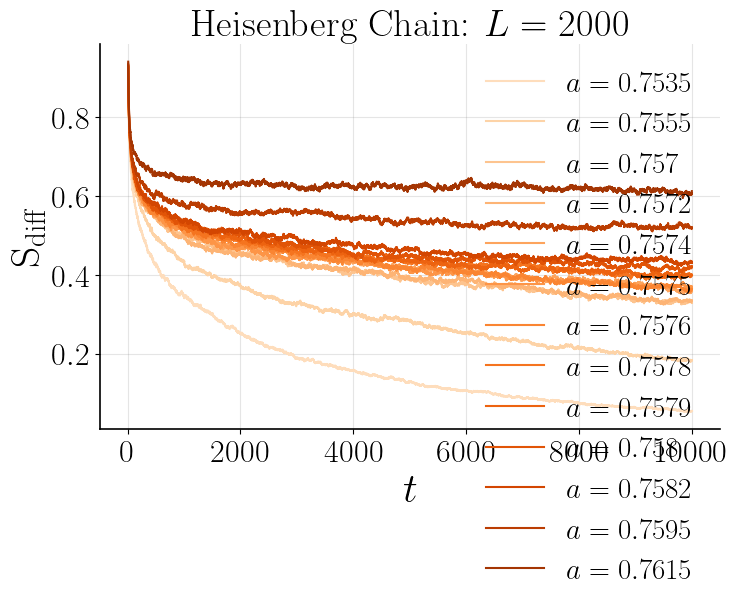

In [10]:
plt.figure(figsize=(8,5))

for j, L in enumerate(L_vals):
    extra_prefact = 1
    if L == 512:
        extra_prefact = 2
    for i, a_val in enumerate(a_vals):
        c = cmaps[L](i+3)
        time_vals = [i * time_step for i in range(0, L*time_prefact * extra_prefact// time_step)][:]
        data_to_plot = collected_sdiffs[L][a_val]
        plt.plot(
            time_vals[10:len(data_to_plot)], 
            data_to_plot[10:], 
            label = fr"$a = {a_val}$",
            # fmt='--',  
            # markersize=3,
            # marker = "o",
            # capsize=3,
            c=c
            )
# plt.axvline(0.29450750, c = 'k', label=f"x = 0.29450750 (old trans)")
plt.title(fr"Heisenberg Chain: $L = {L}$")
plt.xlabel(r"$t$")
plt.ylabel(r"$\mathrm{S_{diff}}$")
plt.legend()
# plt.ylim(0.025, 0.325)

plt.show()


/var/folders/0k/n4x5z88x1rx124p1g1l55hmc0000gn/T/ipykernel_2949/497497188.py:10: RuntimeWarning: divide by zero encountered in log
  log_time_vals = np.log(np.array(time_vals))


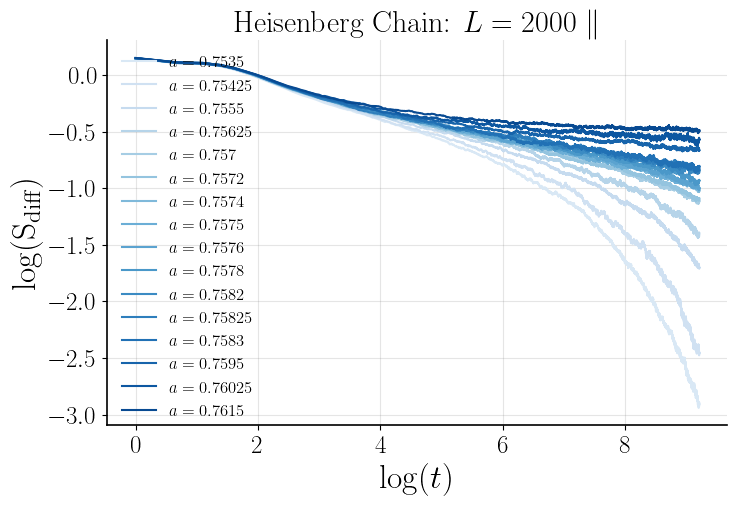

In [8]:
plt.figure(figsize=(8,5))

for j, L in enumerate(L_vals):
    if L == 512:
        extra_prefact = 2
    for i, a_val in enumerate(a_vals):
        c = cmaps[L](i+3)
        data_to_plot = np.log(collected_sdiffs[L][a_val])
        time_vals = [i * time_step for i in range(0, round(L*time_prefact / time_step))][:len(data_to_plot)]
        log_time_vals = np.log(np.array(time_vals))
        plt.plot(
            log_time_vals[1:], 
            data_to_plot[1:], 
            label = fr"$a = {round(a_val, ndigits=7)}$",
            # fmt='--',  
            # markersize=3,
            # marker = "o",
            # capsize=3,
            c=c
            )
# plt.axvline(0.29450750, c = 'k', label=f"x = 0.29450750 (old trans)")
plt.title(fr"Heisenberg Chain: $L = {L}$ $\|$")
plt.xlabel(r"$\log(t)$")
plt.ylabel(r"$\log(\mathrm{S_{diff}})$")
plt.legend()
# plt.ylim(-3.5, 0.5)

plt.show()


In [ ]:
time_vals, len(data_to_plot)

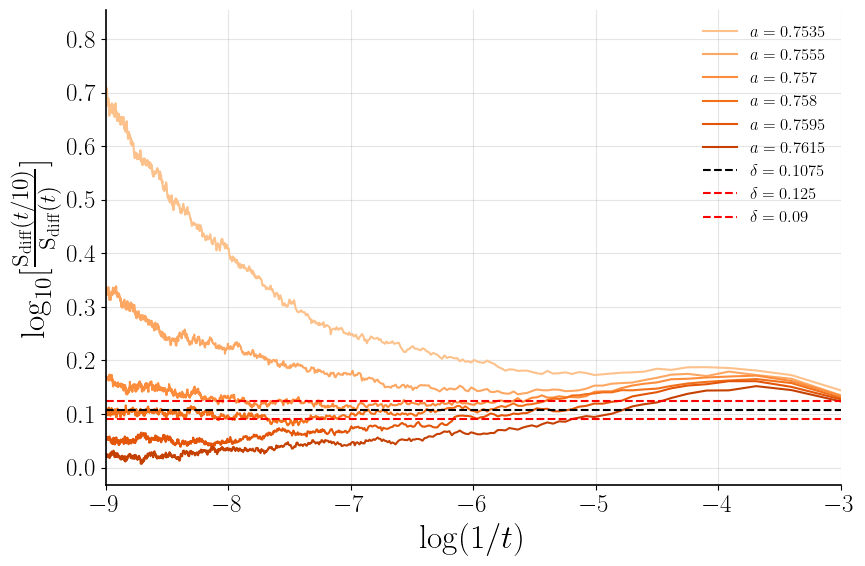

In [72]:
b = 10
delta_guess = 0.1075
cmaps = {2000: plt.colormaps.get_cmap("Oranges").resampled(len(a_vals) + 5), 512: plt.colormaps.get_cmap("Oranges").resampled(len(a_vals) + 5), 1024: plt.colormaps.get_cmap("Reds").resampled(len(a_vals) + 5)}

plt.figure(figsize=(9,6))
for j, L in enumerate(L_vals):
    # if L < max(L_vals):
    #     continue
    for i, a_val in enumerate(a_vals):
        # if a_val == 0.7579 or a_val == 0.7569:
        #     continue
        c = cmaps[L](i+3)
        data_to_plot = (collected_sdiffs[L][a_val])
        t_vals = [(i)*time_step for i in range((len(data_to_plot)//b)) if (i)*time_step]
        time_vals = [i * b*time_step for i in t_vals]
        data_to_plot_numerator = np.array([data_to_plot[(t//(b*time_step))] for t in time_vals])
        data_to_plot_denomenator = np.array([data_to_plot[t//time_step] for t in time_vals])
        data_to_plot = log_b(data_to_plot_numerator[:len(data_to_plot_denomenator)]/data_to_plot_denomenator, 10)

        plt.plot(
            np.log((1/np.array(time_vals))[1:]), 
            data_to_plot[1:], 
            label = fr"$a = {a_val}$",
            # fmt='--',  
            # markersize=3,
            # marker = "o",
            # capsize=3,
            c=c
            )
    
    
plt.axhline(delta_guess, c = 'k', label=fr"$\delta = {delta_guess}$", linestyle ="--")
plt.axhline(0.125, c = 'r', label=fr"$\delta = {0.125}$", linestyle ="--")
plt.axhline(0.09, c = 'r', label=fr"$\delta = {0.09}$", linestyle ="--")
# plt.title(fr"Heisenberg Chain: $L = {L}$ $\|$")
plt.xlabel(r"$\log(1/t)$")
plt.ylabel(r"$\log_{10}[\frac{\mathrm{S_{diff}}(t/10)}{\mathrm{S_{diff}}(t)}]$")
plt.legend()
plt.xlim((-9, -3))
# plt.ylim((0.005, 0.25))
plt.tight_layout()
file_path = f"figs/time_random/delta{str(delta_guess).replace(".", "p")}/spinchain_determining_ac_delta.png"
make_path_exist(file_path)
# plt.savefig(file_path)
plt.show()

> Looks like 
- $a_c \approx 0.7580 \pm 0.0003$
- $\delta \approx 0.1075 \pm 0.002$ 

In [ ]:

fig = plt.figure(figsize=(9,6))
fig.transFigure

figs/time_random/delta0p1075/spinchain_determining_ac_delta.png


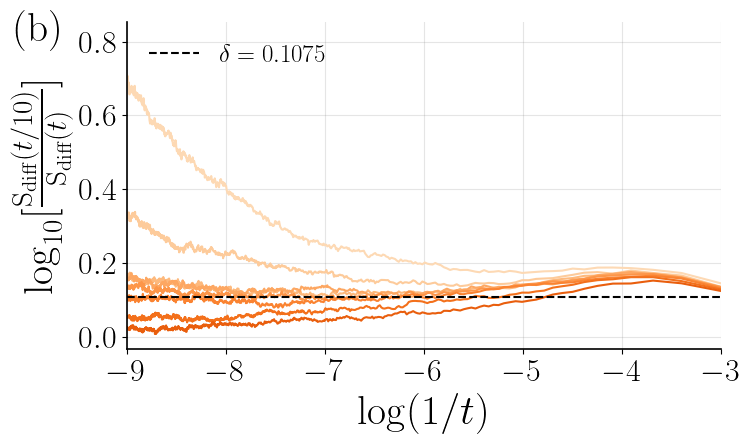

In [72]:
b = 10
delta_guess = 0.1075
# a_vals = sorted(list(set([0.75425, 0.75625, 0.7582,  0.75825, 0.7583,  0.76025,])))
a_vals = [0.7535, 0.7555, 0.757, 0.7572, 0.7574, 0.758, 0.7595, 0.7615]

plt.rcParams["legend.fontsize"] = 18
cmaps = {2000: plt.colormaps.get_cmap("Oranges").resampled(len(a_vals)*2), 512: plt.colormaps.get_cmap("Oranges").resampled(len(a_vals) + 5), 1024: plt.colormaps.get_cmap("Reds").resampled(len(a_vals) + 5)}

fig = plt.figure(figsize=(8,5))
for j, L in enumerate(L_vals):
    # if L < max(L_vals):
    #     continue
    for i, a_val in enumerate(a_vals):
        # if a_val == 0.7579 or a_val == 0.7569:
        #     continue
        c = cmaps[L](i+3)
        data_to_plot = (collected_sdiffs[L][a_val])
        t_vals = [(i)*time_step for i in range((len(data_to_plot)//b)) if (i)*time_step]
        time_vals = [i * b*time_step for i in t_vals]
        data_to_plot_numerator = np.array([data_to_plot[(t//(b*time_step))] for t in time_vals])
        data_to_plot_denomenator = np.array([data_to_plot[t//time_step] for t in time_vals])
        data_to_plot = log_b(data_to_plot_numerator[:len(data_to_plot_denomenator)]/data_to_plot_denomenator, 10)

        plt.plot(
            np.log((1/np.array(time_vals))[1:]), 
            data_to_plot[1:], 
            # label = fr"$a = {a_val}$",
            # fmt='--',  
            # markersize=3,
            # marker = "o",
            # capsize=3,
            c=c
            )
    
plt.axhline(delta_guess, c = 'k', label=fr"$\delta = {delta_guess}$", linestyle ="--")

# plt.title(fr"Heisenberg Chain: $L = {L}$ $\|$")
plt.text(0.05, 0.855, "(b)",
        transform=fig.transFigure, fontsize=plt.rcParams["axes.labelsize"])
plt.xlabel(r"$\log(1/t)$")
plt.ylabel(r"$\log_{10}[\frac{\mathrm{S_{diff}}(t/10)}{\mathrm{S_{diff}}(t)}]$")
plt.legend(loc="upper left")
plt.xlim((-9, -3))
# plt.ylim((0.005, 0.25))


plt.tight_layout()
file_path = f"figs/time_random/delta{str(delta_guess).replace(".", "p")}/spinchain_determining_ac_delta.png"
make_path_exist(file_path)
plt.savefig(file_path)
print(file_path)
plt.show()

Beta 0.2632


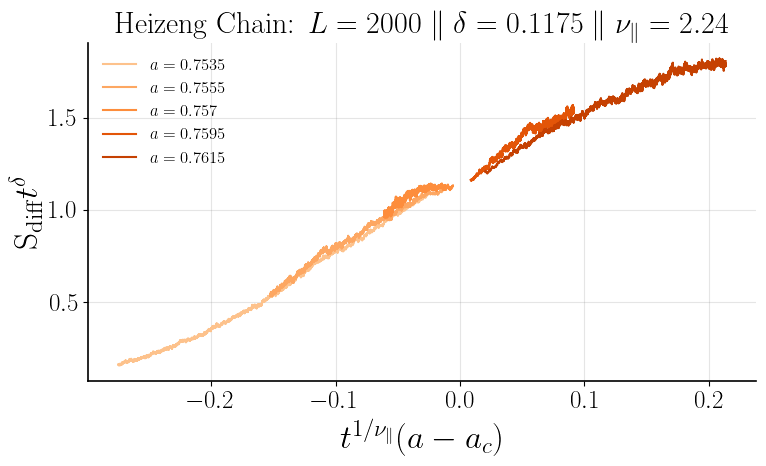

In [ ]:
delta_guess = 0.1175 # pm 0.003
guess_nu_par = 2.24 # pm 0.1
a_c = 0.758 # pm 0.0002
a_vals = [0.7535, 0.7555, 0.757, 0.758, 0.7595, 0.7615]

cmaps = {2000: plt.colormaps.get_cmap("Oranges").resampled(len(a_vals) + 5), 512: plt.colormaps.get_cmap("Oranges").resampled(len(a_vals) + 5), 1024: plt.colormaps.get_cmap("Reds").resampled(len(a_vals) + 5)}

print(f"Beta {delta_guess * guess_nu_par}")
for j, L in enumerate(L_vals):
    if L != max(L_vals):
        continue
    plt.figure(figsize=(8,5))
    for i, a_val in enumerate(a_vals):
        if a_val == a_c or a_val == 0.7579:
            continue
        c = cmaps[L](i+3)
        time_vals = np.array([i * time_step for i in range(0, L*time_prefact // time_step)])
        orig_data = collected_sdiffs[L][a_val][0:len(time_vals)]
        plt.plot(
            (time_vals**(1/guess_nu_par)*(a_val - a_c))[50:], 
            (orig_data * time_vals ** delta_guess)[50:], 
            label = fr"$a = {a_val}$",
            # fmt='--',  
            # markersize=3,
            # marker = "o",
            # capsize=3,
            c=c
            )
        # plt.axvline(finite_sized_time**(1/guess_nu_par)*(a_val-a_c),ymin=0.5, ymax=0.9, c=c)
    
    # plt.axvline(0.29450750, c = 'k', label=f"x = 0.29450750 (old trans)")
    plt.title(fr"Heisen Chain: $L = {L}$ $\|$ $\delta = {delta_guess}$ $\|$ $\nu_{{\|}} = {guess_nu_par}$")
    plt.xlabel(r"$t^{1/\nu}(a - a_c)$")
    plt.ylabel(r"$\mathrm{S_{diff}}t^\delta$")
    plt.legend()
    # plt.xlim(-0.2, 0.2)
    # plt.ylim(0.3, 1.1)

    plt.tight_layout()
    file_path=f"figs/time_random/spin_chain/spinchain_determining_nu_par.png"
    make_path_exist(file_path)
    # plt.savefig(file_path)
    plt.show()

> Looks like 
- $a_c \approx 0.758 \pm 0.0003$
- $\nu \approx 2.24 \pm 0.15$ 
- $\beta \approx 0.230 \pm 0.016$

Beta 0.23
figs/time_random/spin_chain/spinchain_determining_nu_par.png


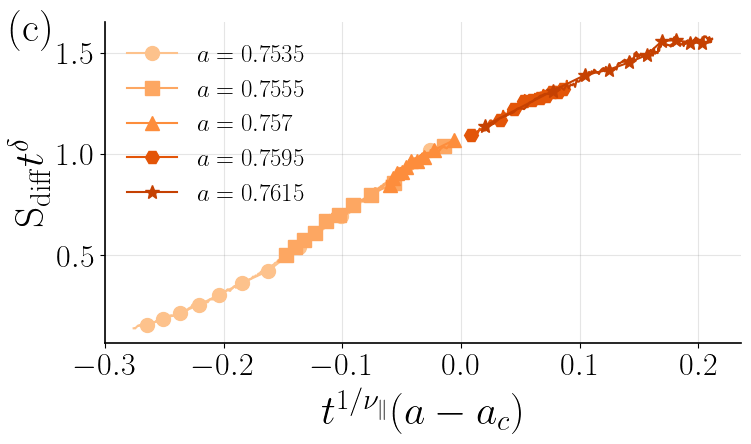

In [ ]:
guess_nu_par = 2.24 # pm 0.1
a_c = 0.758027 # pm 0.0002
beta = 0.23
delta_guess = beta/guess_nu_par # pm 0.003
a_vals = [0.7535, 0.7555, 0.757, 0.758, 0.7595, 0.7615]

plt.rcParams["legend.fontsize"] = 18
cmaps = {2000: plt.colormaps.get_cmap("Oranges").resampled(len(a_vals) + 5), 512: plt.colormaps.get_cmap("Oranges").resampled(len(a_vals) + 5), 1024: plt.colormaps.get_cmap("Reds").resampled(len(a_vals) + 5)}
markers = ['o', 's', '^', 'D', 'H', '*', 'v', '<', '>',  'd', 'p', 'h', 'X', 'P', '+', 'x', '|', '_', ]

print(f"Beta {delta_guess * guess_nu_par}")
for j, L in enumerate(L_vals):
    if L != max(L_vals):
        continue
    fig = plt.figure(figsize=(8,5))
    for i, a_val in enumerate(a_vals):
        if abs(a_val - a_c) <= 0.001:
            continue
        c = cmaps[L](i+3)
        time_vals = np.array([i * time_step for i in range(0, L*time_prefact // time_step)])
        orig_data = collected_sdiffs[L][a_val][0:len(time_vals)]
        plt.plot(
            (time_vals**(1/guess_nu_par)*(a_val - a_c))[50::50], 
            (orig_data * time_vals ** delta_guess)[50::50], 
            # label = fr"$a = {a_val}$",
            # fmt='--',  
            # markersize=3,
            # marker = "o",
            # capsize=3,
            c=c
            )
        plt.plot(
            (time_vals**(1/guess_nu_par)*(a_val - a_c))[50::1000], 
            (orig_data * time_vals ** delta_guess)[50::1000], 
            label = fr"$a = {a_val}$",
            # fmt='--',  
            markersize=10,
            marker = markers[i],
            # capsize=3,
            c=c
            )
        # plt.axvline(finite_sized_time**(1/guess_nu_par)*(a_val-a_c),ymin=0.5, ymax=0.9, c=c)
    
    # plt.axvline(0.29450750, c = 'k', label=f"x = 0.29450750 (old trans)")
    # plt.title(fr"Heisen Chain: $L = {L}$ $\|$ $\delta = {delta_guess}$ $\|$ $\nu_{{\|}} = {guess_nu_par}$")
    plt.text(0.043, 0.855, "(c)", fontsize=plt.rcParams["axes.labelsize"],
        transform=fig.transFigure)
    plt.xlabel(r"$t^{1/\nu}(a - a_c)$")
    plt.ylabel(r"$\mathrm{S_{diff}}t^{\delta}$")
    plt.legend()
    # plt.xlim(-0.2, 0.2)
    # plt.ylim(0.3, 1.1)

    plt.tight_layout()
    file_path=f"figs/time_random/spin_chain/spinchain_determining_nu_par.png"
    make_path_exist(file_path)
    plt.savefig(file_path)
    print(file_path)
    plt.show()

Beta 0.23
figs/time_random/spin_chain/spinchain_determining_nu_par.png


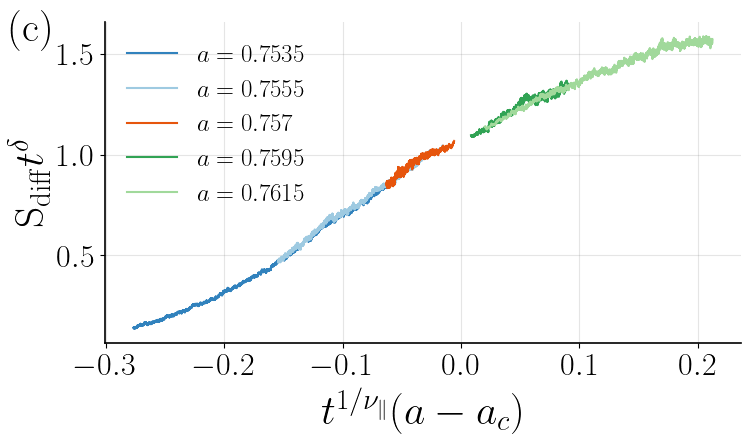

In [ ]:
guess_nu_par = 2.24 # pm 0.1
a_c = 0.758027 # pm 0.0002
beta = 0.23
delta_guess = beta/guess_nu_par # pm 0.003
a_vals = [0.7535, 0.7555, 0.757, 0.758, 0.7595, 0.7615]

plt.rcParams["legend.fontsize"] = 18
cmaps = {2000: plt.colormaps.get_cmap("tab20c").resampled(len(a_vals) + 5), 512: plt.colormaps.get_cmap("Oranges").resampled(len(a_vals) + 5), 1024: plt.colormaps.get_cmap("Reds").resampled(len(a_vals) + 5)}
# markers = ['o', 's', '^', 'D', 'H', '*', 'v', '<', '>',  'd', 'p', 'h', 'X', 'P', '+', 'x', '|', '_', ]

print(f"Beta {delta_guess * guess_nu_par}")
for j, L in enumerate(L_vals):
    if L != max(L_vals):
        continue
    fig = plt.figure(figsize=(8,5))
    for i, a_val in enumerate(a_vals):
        if abs(a_val - a_c) <= 0.001:
            continue
        c = cmaps[L](i)
        time_vals = np.array([i * time_step for i in range(0, L*time_prefact // time_step)])
        orig_data = collected_sdiffs[L][a_val][0:len(time_vals)]
        plt.plot(
            (time_vals**(1/guess_nu_par)*(a_val - a_c))[50:], 
            (orig_data * time_vals ** delta_guess)[50:], 
            label = fr"$a = {a_val}$",
            # fmt='--',  
            # markersize=3,
            # marker = "o",
            # capsize=3,
            c=c
            )
        # plt.axvline(finite_sized_time**(1/guess_nu_par)*(a_val-a_c),ymin=0.5, ymax=0.9, c=c)
    
    # plt.axvline(0.29450750, c = 'k', label=f"x = 0.29450750 (old trans)")
    # plt.title(fr"Heisen Chain: $L = {L}$ $\|$ $\delta = {delta_guess}$ $\|$ $\nu_{{\|}} = {guess_nu_par}$")
    plt.text(0.043, 0.855, "(c)", fontsize=plt.rcParams["axes.labelsize"],
        transform=fig.transFigure)
    plt.xlabel(r"$t^{1/\nu}(a - a_c)$")
    plt.ylabel(r"$\mathrm{S_{diff}}t^{\delta}$")
    plt.legend()
    # plt.xlim(-0.2, 0.2)
    # plt.ylim(0.3, 1.1)

    plt.tight_layout()
    file_path=f"figs/time_random/spin_chain/spinchain_determining_nu_par.png"
    make_path_exist(file_path)
    plt.savefig(file_path)
    print(file_path)
    plt.show()

figs/time_random/delta0p1075/spinchain_determining_ac_delta_nu_par.png


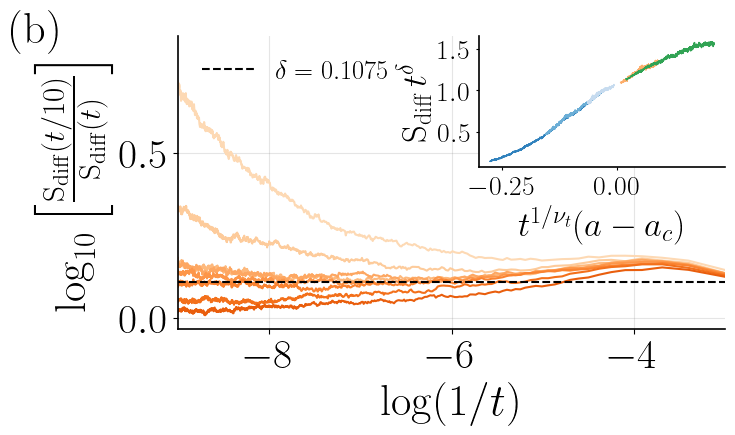

In [6]:
b = 10
delta_guess = 0.1075
a_vals = [0.7535, 0.7555, 0.757, 0.7572, 0.7574, 0.758, 0.7595, 0.7615]

guess_nu_par = 2.24
a_c = 0.758027
beta = 0.23
delta_guess_c = beta / guess_nu_par

plt.rcParams["font.size"] = 30
plt.rcParams["axes.labelsize"] = 32
plt.rcParams["legend.fontsize"] = 19
cmaps = {
    2000: plt.colormaps.get_cmap("Oranges").resampled(len(a_vals) * 2),
    512:  plt.colormaps.get_cmap("Oranges").resampled(len(a_vals) + 5),
    1024: plt.colormaps.get_cmap("Reds").resampled(len(a_vals) + 5),
}
cmaps_c = {
    2000: plt.colormaps.get_cmap("tab20c").resampled(len(a_vals) + 5),
    512:  plt.colormaps.get_cmap("Oranges").resampled(len(a_vals) + 5),
    1024: plt.colormaps.get_cmap("Reds").resampled(len(a_vals) + 5),
}

fig, ax = plt.subplots(figsize=(8, 5))

# --- Inset axes (plot c content) ---
ax_inset = ax.inset_axes([0.55, 0.55, 0.45, 0.45])

# --- Main plot (b) ---
for j, L in enumerate(L_vals):
    for i, a_val in enumerate(a_vals):
        c = cmaps[L](i + 3)
        data_to_plot = collected_sdiffs[L][a_val]
        t_vals = [(i) * time_step for i in range((len(data_to_plot) // b)) if (i) * time_step]
        time_vals = [i * b * time_step for i in t_vals]
        data_to_plot_numerator = np.array([data_to_plot[(t // (b * time_step))] for t in time_vals])
        data_to_plot_denominator = np.array([data_to_plot[t // time_step] for t in time_vals])
        data_to_plot_ratio = log_b(
            data_to_plot_numerator[:len(data_to_plot_denominator)] / data_to_plot_denominator, 10
        )

        ax.plot(
            np.log((1 / np.array(time_vals))[1:]),
            data_to_plot_ratio[1:],
            c=c
        )

ax.axhline(delta_guess, c='k', label=fr"$\delta = {delta_guess}$", linestyle="--")
ax.text(0.05, 0.855, "(b)", transform=fig.transFigure, fontsize=plt.rcParams["axes.labelsize"])
ax.set_xlabel(r"$\log(1/t)$")
ax.set_ylabel(r"$\log_{10}\left[\frac{\mathrm{S_{diff}}(t/10)}{\mathrm{S_{diff}}(t)}\right]$")
ax.legend(loc="upper left")
ax.set_xlim((-9, -3))

# --- Inset (plot c content) ---
a_vals_c = [0.7535, 0.7555, 0.757, 0.758, 0.7595, 0.7615]
for j, L in enumerate(L_vals):
    if L != max(L_vals):
        continue
    for i, a_val in enumerate(a_vals_c):
        if abs(a_val - a_c) <= 0.001:
            continue
        c = cmaps_c[L](i)
        time_vals = np.array([i * time_step for i in range(0, L * time_prefact // time_step)])
        orig_data = collected_sdiffs[L][a_val][0:len(time_vals)]
        ax_inset.plot(
            (time_vals ** (1 / guess_nu_par) * (a_val - a_c))[50:],
            (orig_data * time_vals ** delta_guess_c)[50:],
            c=c,
            lw=0.9
        )

# --- Inset formatting ---
ax_inset.grid(False)
ax_inset.set_xlabel(r"$t^{1/\nu_t}(a - a_c)$", fontsize=25)
ax_inset.set_ylabel(r"$\mathrm{S_{diff}}\,t^{\delta}$", fontsize=25)
ax_inset.tick_params(labelbottom=True, labelleft=True, length=2, labelsize=20)
ax_inset.set_facecolor(fig.get_facecolor())

fig.tight_layout()

file_path = f"figs/time_random/delta{str(delta_guess).replace('.', 'p')}/spinchain_determining_ac_delta_nu_par.png"
make_path_exist(file_path)
plt.savefig(file_path)
print(file_path)
plt.show()